
# CBottle สุดยอดความละเอียด

สภาพภูมิอากาศในขวด (cBottle) workflows ที่มีความละเอียดสูงสุดสำหรับสภาพอากาศทั่วโลก

ตัวอย่างนี้จะสาธิตโมเดลการแพร่กระจายของ cBottle สำหรับความละเอียดสูงสุดระดับโลก
ข้อมูลสภาพอากาศ โมเดล CBottleSR ใช้ข้อมูลสภาพภูมิอากาศความละเอียดต่ำและสร้าง
เอาต์พุตที่มีความละเอียดสูงโดยใช้วิธีการแพร่กระจาย

ดูข้อมูลเพิ่มเติมเกี่ยวกับ cBottle ได้ที่:

- https://arxiv.org/abs/2505.06474v1

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- ดำเนินการความละเอียดสูงสุดกับข้อมูลสังเคราะห์จากแหล่งข้อมูล cBottle
- ดำเนินการความละเอียดสูงสุดกับข้อมูล ERA5 หลังจากเติม cBottle
- การประมวลผลภายหลังและการแสดงภาพผลลัพธ์ที่มีความละเอียดสูงสุด


In [1]:
# /// script
# dependencies = [
#   "earth2studio[cbottle] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
# ]
# ///

## การเตรียมองค์ประกอบ
สำหรับตัวอย่างนี้ เราจะใช้แหล่งข้อมูล cBottle การวินิจฉัยการเติม และ
CBottleSR รุ่นความละเอียดสูงพิเศษ workflow สาธิตสองวิธี:

1. ความละเอียดขั้นสูงของข้อมูลสังเคราะห์ที่สร้างโดย cBottle3D
2. ความละเอียดสูงสุดบนข้อมูล ERA5 จริงหลังจากการเติมตัวแปร



เราจำเป็นต้องมีคอมโพเนนต์ต่อไปนี้:

- Datasource: สร้างข้อมูลจาก CBottle3D data API ผ่าน :py:class:`earth2studio.data.CBottle3D`.
- Datasource: ดึงข้อมูลจาก WeatherBench2 data API ผ่าน :py:class:`earth2studio.data.WB2ERA5`.
- Diagnostic Model: ใช้ CBottle Infill Model :py:class:`earth2studio.models.dx.CBottleInfill` ในตัว
- รุ่นความละเอียดสูงพิเศษ: ใช้รุ่นความละเอียดสูงพิเศษ CBottleSR :py:class:`earth2studio.models.dx.CBottleSR`



In [2]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

import torch

from earth2studio.data import WB2ERA5, CBottle3D, fetch_data
from earth2studio.models.dx import CBottleInfill, CBottleSR

# รับอุปกรณ์
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# โหลดแหล่งข้อมูล cBottle
package = CBottle3D.load_default_package()
cbottle_ds = CBottle3D.load_model(package)

# โหลดโมเดลที่มีความละเอียดสูงสุด
super_resolution_window = (
    0,
    -120,
    50,
    -40,
)  # (ลาดใต้, ลอนตะวันตก, ลาดเหนือ, ตะวันออก)
package = CBottleSR.load_default_package()
cbottle_sr = CBottleSR.load_model(
    package,
    output_resolution=(1024, 1024),
    super_resolution_window=super_resolution_window,
    distilled_model=True,
)

# โหลดโมเดล infill
input_variables = ["u10m", "v10m"]
package = CBottleInfill.load_default_package()
cbottle_infill = CBottleInfill.load_model(
    package, input_variables=input_variables, sampler_steps=18
)

# โหลดแหล่งข้อมูล ERA5
era5_ds = WB2ERA5()

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


## ความละเอียดขั้นสูงของข้อมูลสังเคราะห์
ขั้นแรก เรามาสร้างข้อมูลสภาพภูมิอากาศสังเคราะห์โดยใช้แหล่งข้อมูล cBottle3D กัน
จากนั้นจึงใช้ความละเอียดสูงสุดกับมัน นี่แสดงให้เห็นถึง cBottle เต็มรูปแบบ
ไปป์ไลน์ตั้งแต่การสร้างข้อมูลไปจนถึงการปรับปรุงความละเอียดสูงพิเศษ



In [3]:
import datetime

import numpy as np

from earth2studio.utils.coords import map_coords

times = np.array([datetime.datetime(2020, 1, 1)], dtype="datetime64[ns]")

# สร้างตัวอย่างบางส่วนจาก cBottle
cbottle_ds = cbottle_ds.to(device)
synth_x, synth_coords = fetch_data(
    cbottle_ds,
    times,
    cbottle_sr.input_coords()["variable"],
    device=device,
)
del cbottle_ds  # ทำความสะอาดโมเดลแหล่งข้อมูลเพื่อเพิ่มหน่วยความจำ GPU

# ทำความละเอียดสูงสุดกับข้อมูลสังเคราะห์
cbottle_sr = cbottle_sr.to(device)
synth_x, synth_coords = map_coords(synth_x, synth_coords, cbottle_sr.input_coords())
sr_synth_x, sr_synth_coords = cbottle_sr(synth_x, synth_coords)

Generating cBottle Data: 100%|██████████| 1/1 [00:13<00:00, 13.49s/it]


## ความละเอียดขั้นสูงของข้อมูล ERA5
ต่อไป เราจะสาธิตความละเอียดสูงสุดบนข้อมูล ERA5 จริง เนื่องจาก ERA5 ไม่มี
ประกอบด้วยตัวแปรทั้งหมดที่จำเป็นสำหรับ CBottleSR อันดับแรกเราจะใช้ CBottleInfill
เพื่อทำนายตัวแปรที่หายไป จากนั้นจึงดำเนินการแบบความละเอียดสูงสุด



In [4]:
# รับข้อมูล ERA5 (ใช้ได้เฉพาะ u10m และ v10m เท่านั้น)
era5_x, era5_coords = fetch_data(
    era5_ds,
    times,
    input_variables,
    device=device,
)

# ดำเนินการเติมเพื่อรับตัวแปรที่จำเป็นทั้งหมด
cbottle_infill = cbottle_infill.to(device)
infill_x, infill_coords = cbottle_infill(era5_x, era5_coords)
del cbottle_infill  # ทำความสะอาดโมเดล infill เพื่อเพิ่มหน่วยความจำ GPU

# เลือกตัวแปรที่ต้องการและปรับรูปร่างใหม่เพื่อให้ได้ความละเอียดสูงสุด
infill_x, infill_coords = map_coords(infill_x, infill_coords, cbottle_sr.input_coords())
sr_infill_x, sr_infill_coords = cbottle_sr(infill_x, infill_coords)

Fetching WB2 data:   0%|          | 0/2 [00:00<?, ?it/s]

2026-04-24 15:14:28.445 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2020-01-01T00:00:00
2026-04-24 15:14:28.447 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2020-01-01T00:00:00


Fetching WB2 data:   0%|          | 0/2 [00:00<?, ?it/s]

2026-04-24 15:14:28.720 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/10m_v_component_of_wind/89120.0.0 to local cache
2026-04-24 15:14:28.735 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/10m_u_component_of_wind/89120.0.0 to local cache


Fetching WB2 data: 100%|██████████| 2/2 [00:03<00:00,  1.50s/it]


## การประมวลผลภายหลัง CBottle ข้อมูลความละเอียดสูงสุด
เรามาดูผลลัพธ์ที่มีความละเอียดสูงสุดเพื่อเปรียบเทียบข้อมูลสังเคราะห์กัน
เข้าใกล้ด้วยวิธีเติม ERA5 เราจะพล็อตของเหลวเมฆทั้งหมด
ตัวแปรน้ำ (tclw) เป็นตัวอย่าง



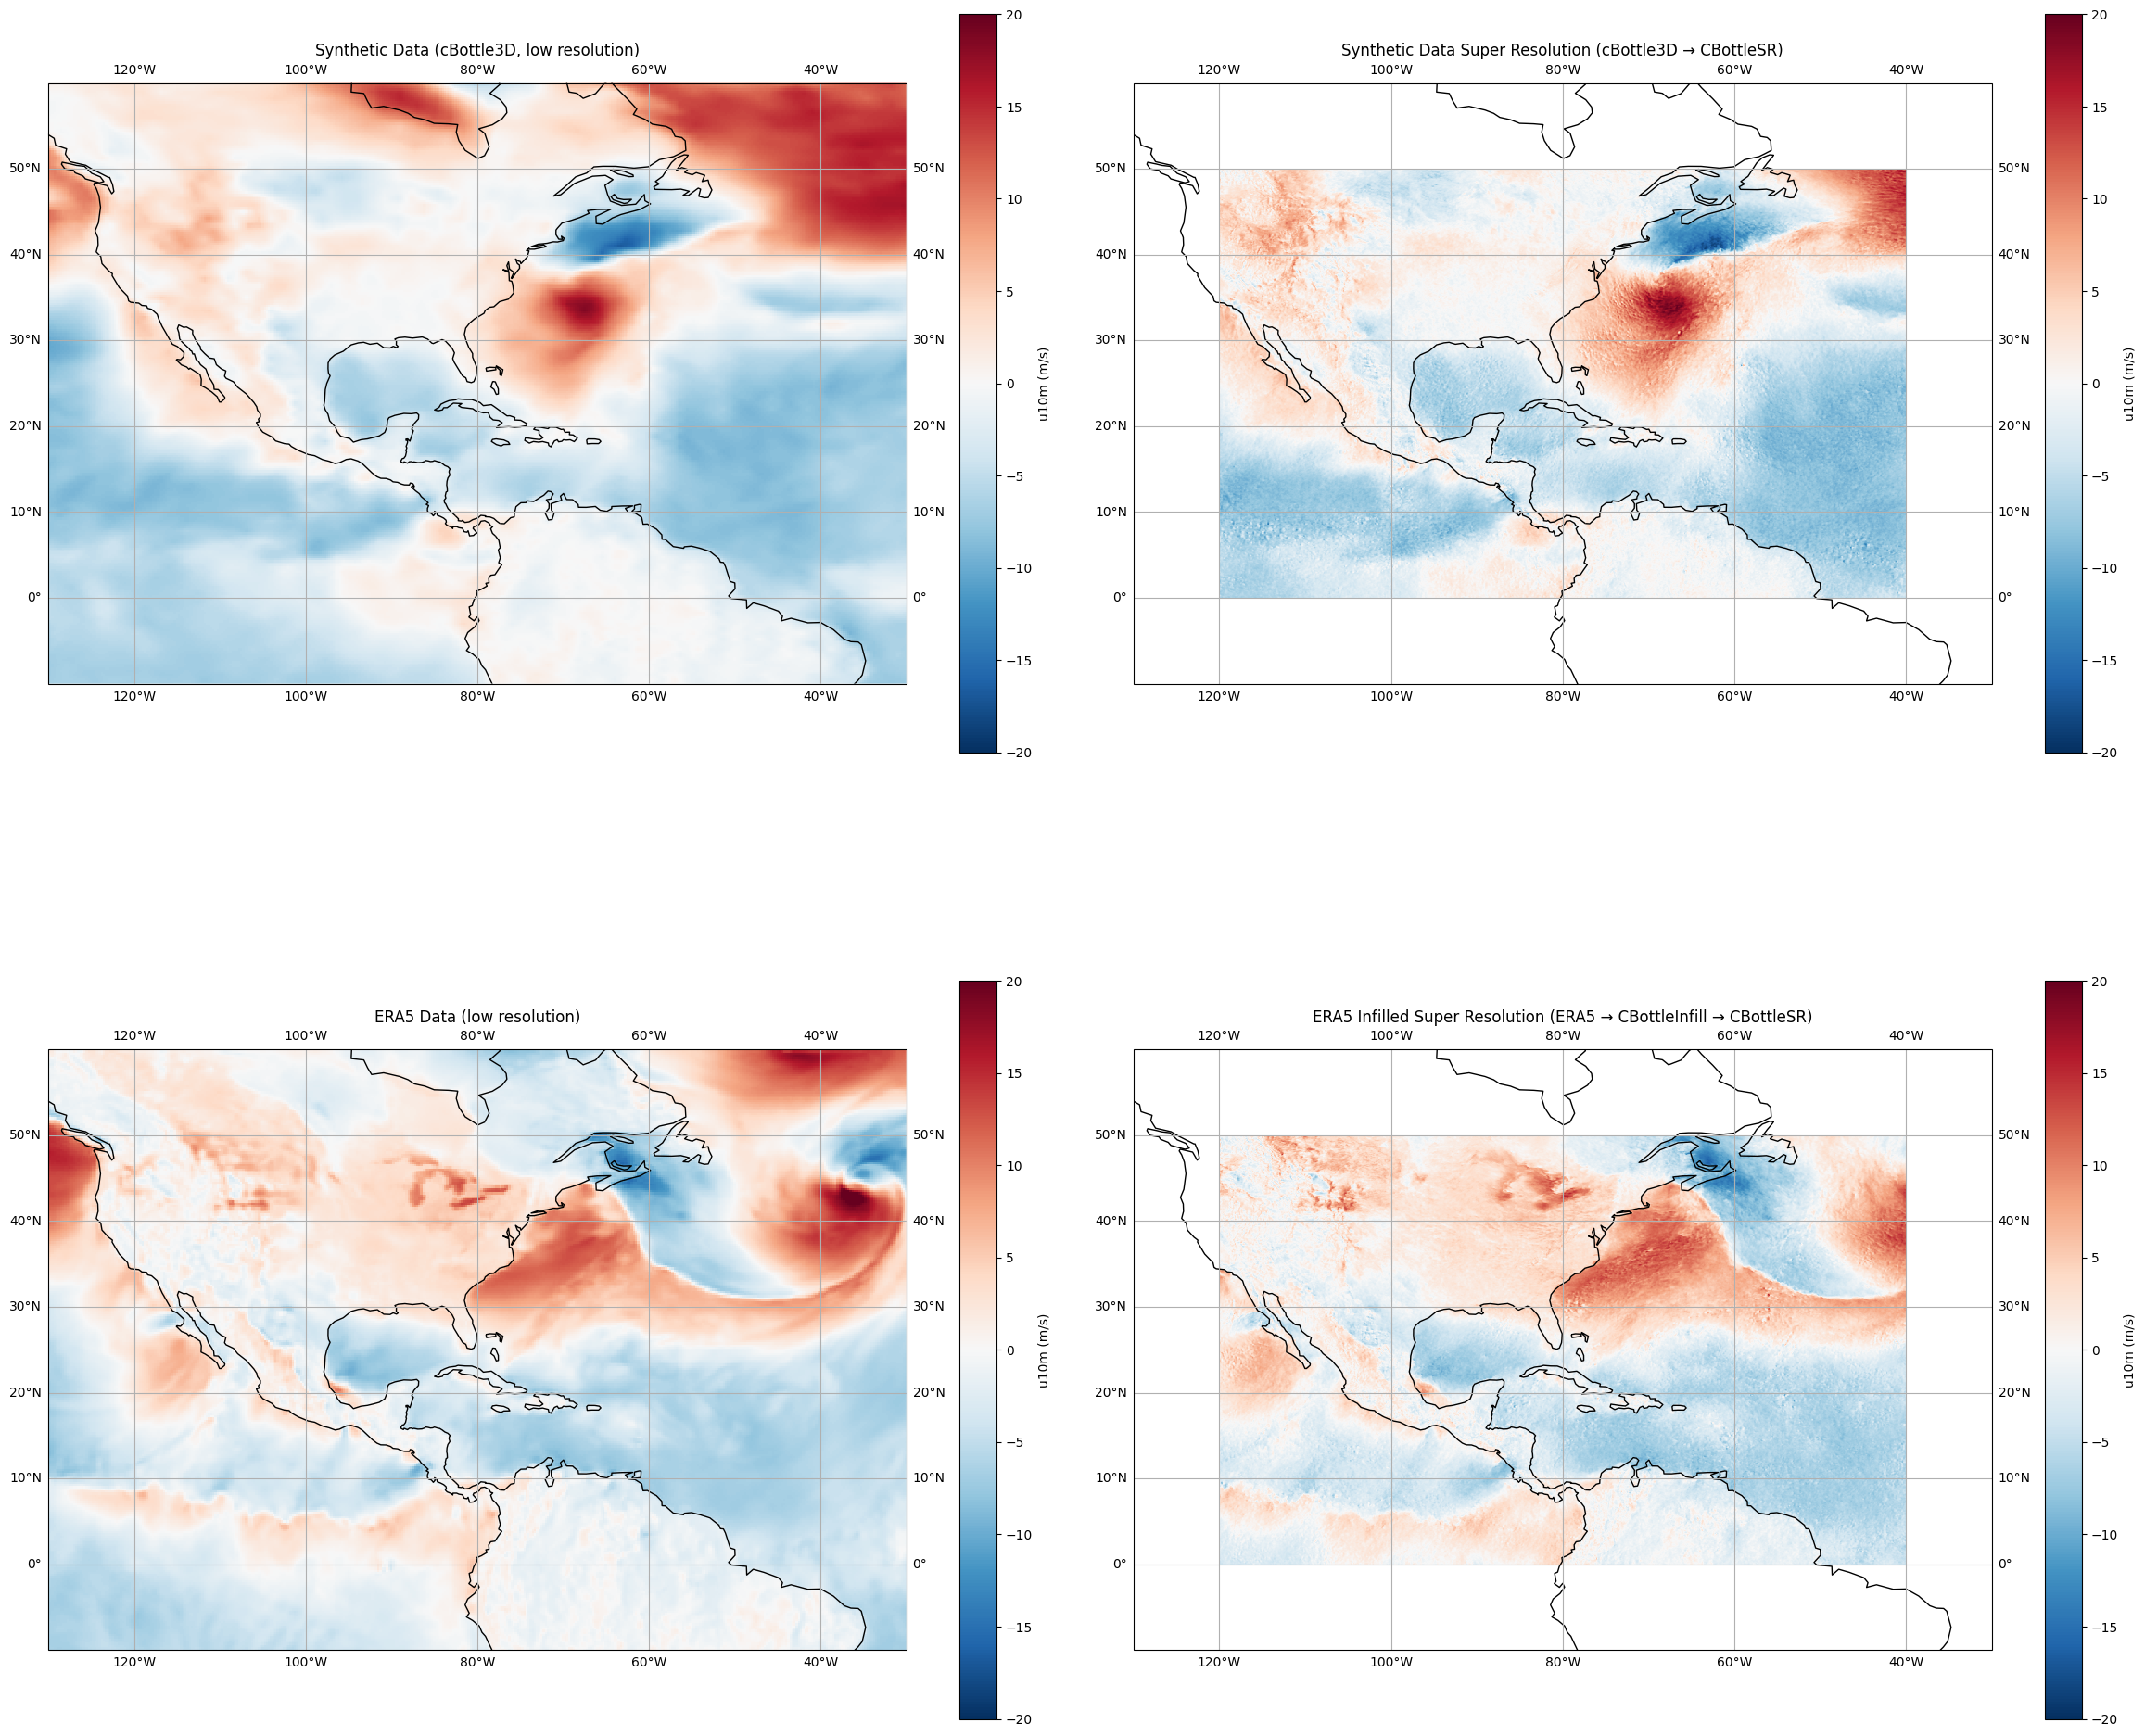

In [5]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

plt.close("all")

# สร้าง projection ที่มุ่งเน้นไปที่ภูมิภาคที่น่าสนใจ (แอตแลนติกเหนือ/ยุโรป)
projection = ccrs.PlateCarree()
fig = plt.figure(figsize=(24, 24))

# ลงจุดข้อมูลสังเคราะห์
ax0 = fig.add_subplot(2, 2, 1, projection=projection)
extent = [
    super_resolution_window[1] - 10,
    super_resolution_window[3] + 10,
    super_resolution_window[0] - 10,
    super_resolution_window[2] + 10,
]
ax0.set_extent(extent, crs=ccrs.PlateCarree())
c = ax0.pcolormesh(
    synth_coords["lon"],
    synth_coords["lat"],
    synth_x[0, 0, 3, :, :].cpu().numpy(),  # u10m (ดัชนีตัวแปร 3)
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-20,
    vmax=20,
)
plt.colorbar(c, ax=ax0, shrink=0.6, label="u10m (m/s)")
ax0.coastlines()
ax0.gridlines(draw_labels=True)
ax0.set_title("Synthetic Data (cBottle3D, low resolution)")

# พล็อตข้อมูลความละเอียดสูงสุดสังเคราะห์
ax1 = fig.add_subplot(2, 2, 2, projection=projection)
ax1.set_extent(extent, crs=ccrs.PlateCarree())
c = ax1.pcolormesh(
    sr_synth_coords["lon"],
    sr_synth_coords["lat"],
    sr_synth_x[0, 0, 3, :, :].cpu().numpy(),  # u10m (ดัชนีตัวแปร 3)
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-20,
    vmax=20,
)
plt.colorbar(c, ax=ax1, shrink=0.6, label="u10m (m/s)")
ax1.coastlines()
ax1.gridlines(draw_labels=True)
ax1.set_title("Synthetic Data Super Resolution (cBottle3D → CBottleSR)")

# พล็อตข้อมูล ERA5
ax2 = fig.add_subplot(2, 2, 3, projection=projection)
ax2.set_extent(extent, crs=ccrs.PlateCarree())
c = ax2.pcolormesh(
    era5_coords["lon"],
    era5_coords["lat"],
    era5_x[0, 0, 0, :, :].cpu().numpy(),  # u10m (ดัชนีตัวแปร 0)
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-20,
    vmax=20,
)
plt.colorbar(c, ax=ax2, shrink=0.6, label="u10m (m/s)")
ax2.coastlines()
ax2.gridlines(draw_labels=True)
ax2.set_title("ERA5 Data (low resolution)")

# พล็อตข้อมูลความละเอียดสูงสุดที่เติม ERA5
ax3 = fig.add_subplot(2, 2, 4, projection=projection)
ax3.set_extent(extent, crs=ccrs.PlateCarree())
c = ax3.pcolormesh(
    sr_infill_coords["lon"],
    sr_infill_coords["lat"],
    sr_infill_x[0, 0, 3, :, :].cpu().numpy(),  # u10m (ดัชนีตัวแปร 3)
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-20,
    vmax=20,
)
plt.colorbar(c, ax=ax3, shrink=0.6, label="u10m (m/s)")
ax3.coastlines()
ax3.gridlines(draw_labels=True)
ax3.set_title("ERA5 Infilled Super Resolution (ERA5 → CBottleInfill → CBottleSR)")

plt.tight_layout()
plt.savefig("outputs/16_cbottle_super_resolution.jpg", dpi=150, bbox_inches="tight")